# Regression by Minimizing Absolute Deviation — Experimental Workflow

This notebook contains only the experimental workflow: data preparation, model fitting, evaluation, visualizations, controlled experiments, runtime benchmarking, validation, and generated outputs.


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display, Image

from absolute_deviation.data import DATASETS, load_dataset
from absolute_deviation.experiments import (
    FIGURE_DIR,
    RESULT_DIR,
    run_original_data,
    run_contamination_experiment,
    run_error_distribution_experiment,
    run_runtime_benchmark,
    validate_lad_solver,
)
from absolute_deviation.plotting import (
    generate_all_figures,
    plot_real_dataset_predictions,
    plot_hbk_multivariate_inlier_outlier,
    plot_unlabeled_multivariate_residual_space,
)


## 1. Data preparation


In [2]:
dataset_rows = []
for name in DATASETS:
    X, y, predictors = load_dataset(name)
    dataset_rows.append({
        "dataset": name,
        "observations": len(y),
        "predictors": X.shape[1],
        "predictor_names": ", ".join(predictors),
    })

dataset_summary = pd.DataFrame(dataset_rows)
display(dataset_summary)


,dataset,observations,predictors,predictor_names
0,boston_housing,506,12,"CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD,..."
1,concrete_strength,1030,8,"Cement, BlastFurnaceSlag, FlyAsh, Water, Super..."
2,hbk,75,3,"X1, X2, X3"


## 2. Fit OLS and LAD on the empirical datasets


In [3]:
original_metrics, original_coefficients = run_original_data()

display(original_metrics)
display(original_coefficients.head(20))


,dataset,model,SSE,SAE
0,boston_housing,OLS,11349.418808,1698.290859
1,boston_housing,LAD,12469.793173,1611.011000
2,concrete_strength,OLS,110428.156817,8461.346375
3,concrete_strength,LAD,119464.579642,8289.485903
4,hbk,OLS,359.485726,103.468960
5,hbk,LAD,587.732546,86.742870


,dataset,model,term,estimate
0,boston_housing,OLS,Intercept,41.617270
1,boston_housing,OLS,CRIM,-0.121389
2,boston_housing,OLS,ZN,0.046963
3,boston_housing,OLS,INDUS,0.013468
4,boston_housing,OLS,CHAS,2.839993
5,boston_housing,OLS,NOX,-18.758022
6,boston_housing,OLS,RM,3.658119
7,boston_housing,OLS,AGE,0.003611
8,boston_housing,OLS,DIS,-1.490754
9,boston_housing,OLS,RAD,0.289405


## 3. Empirical visualizations


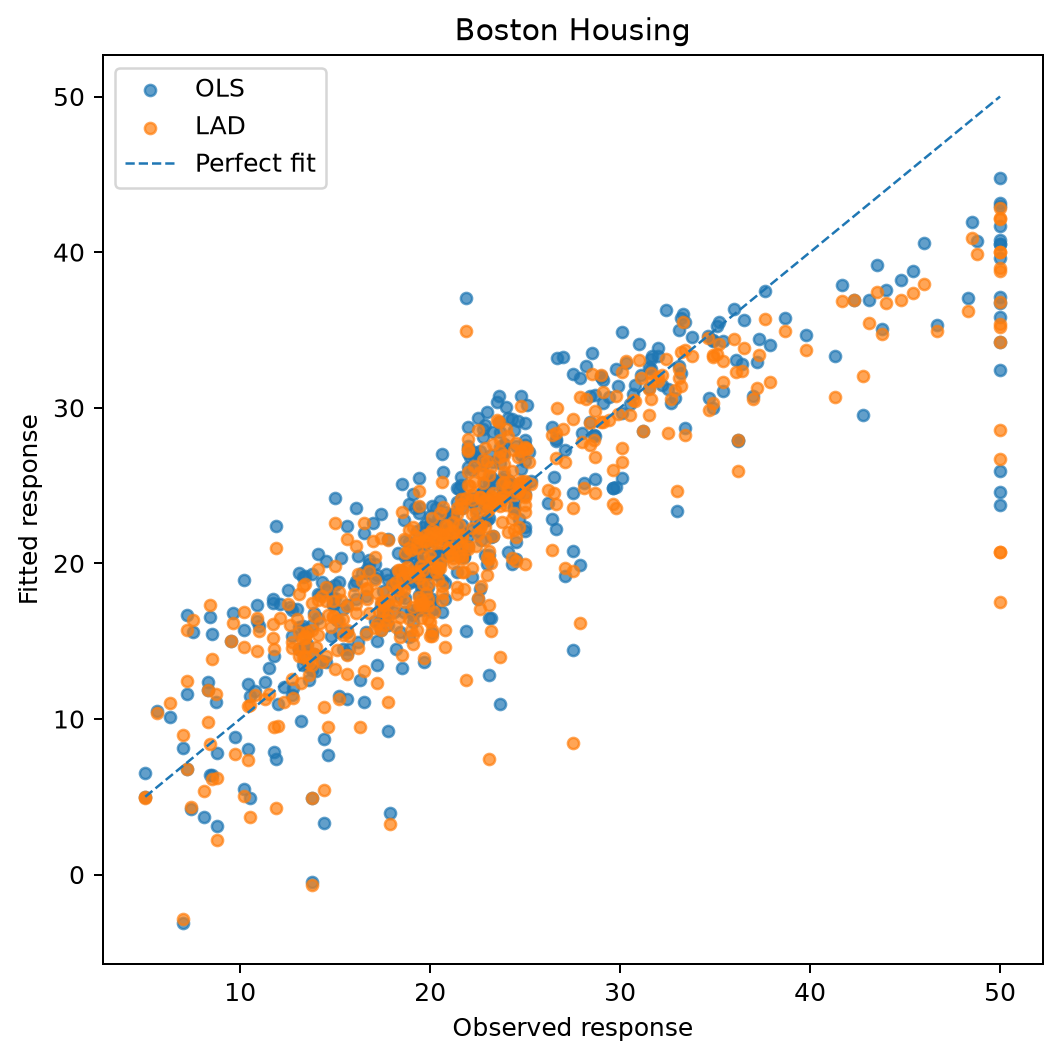

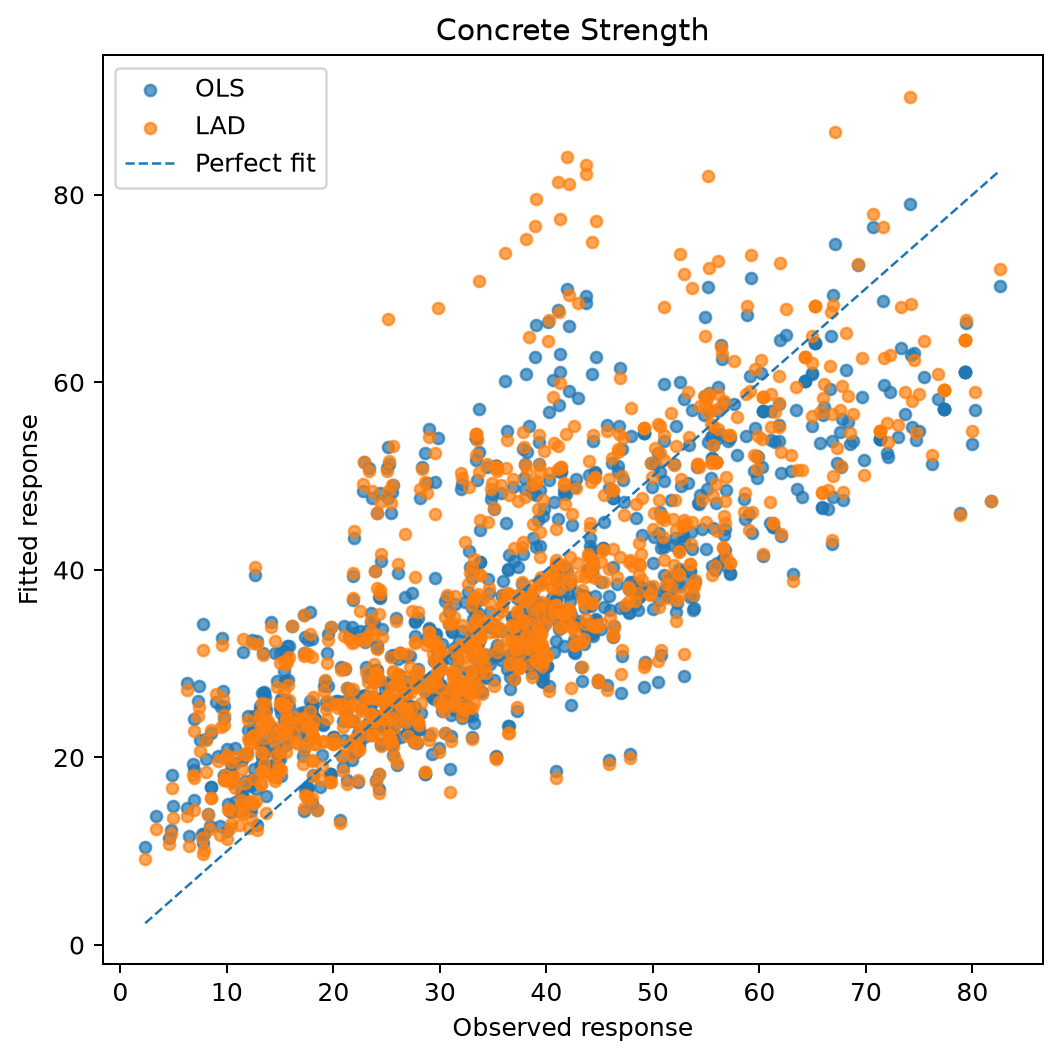

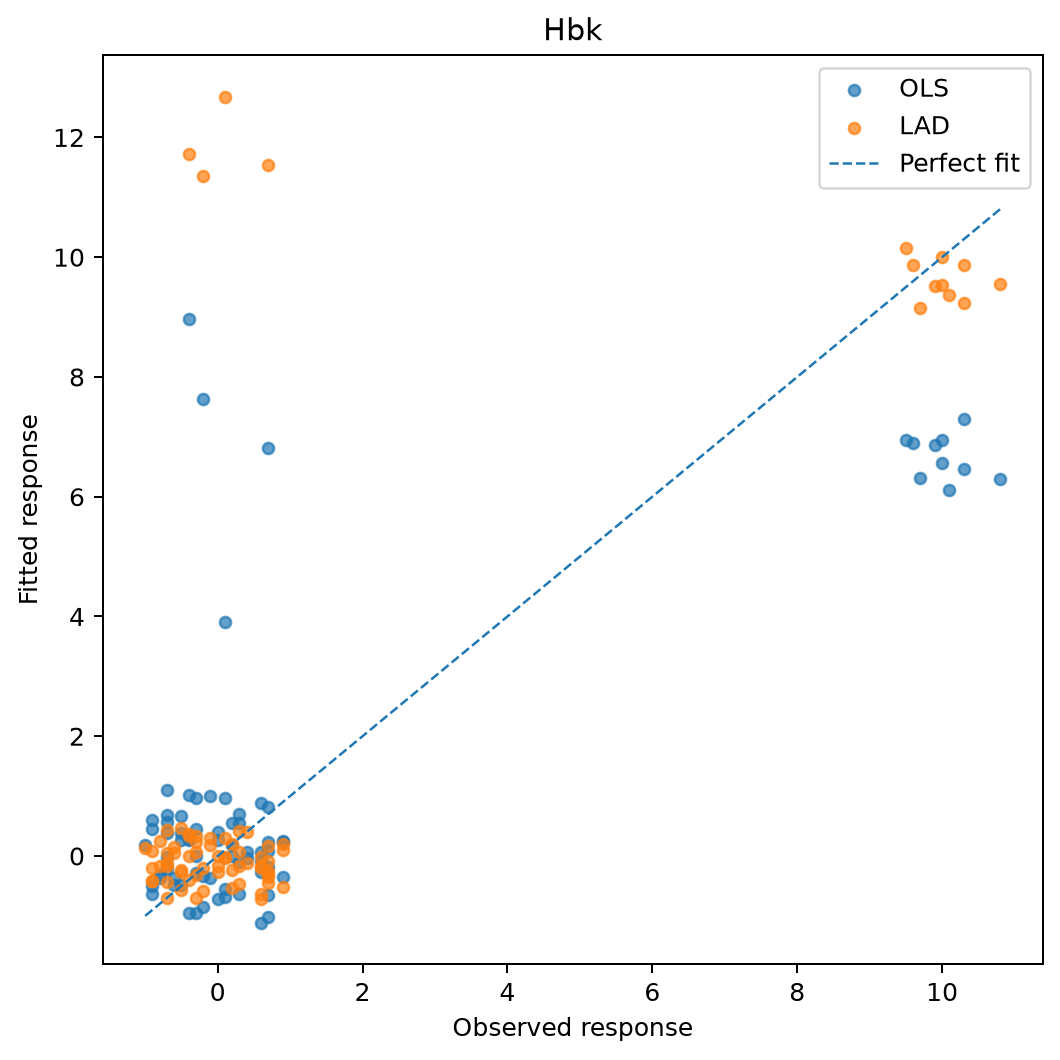

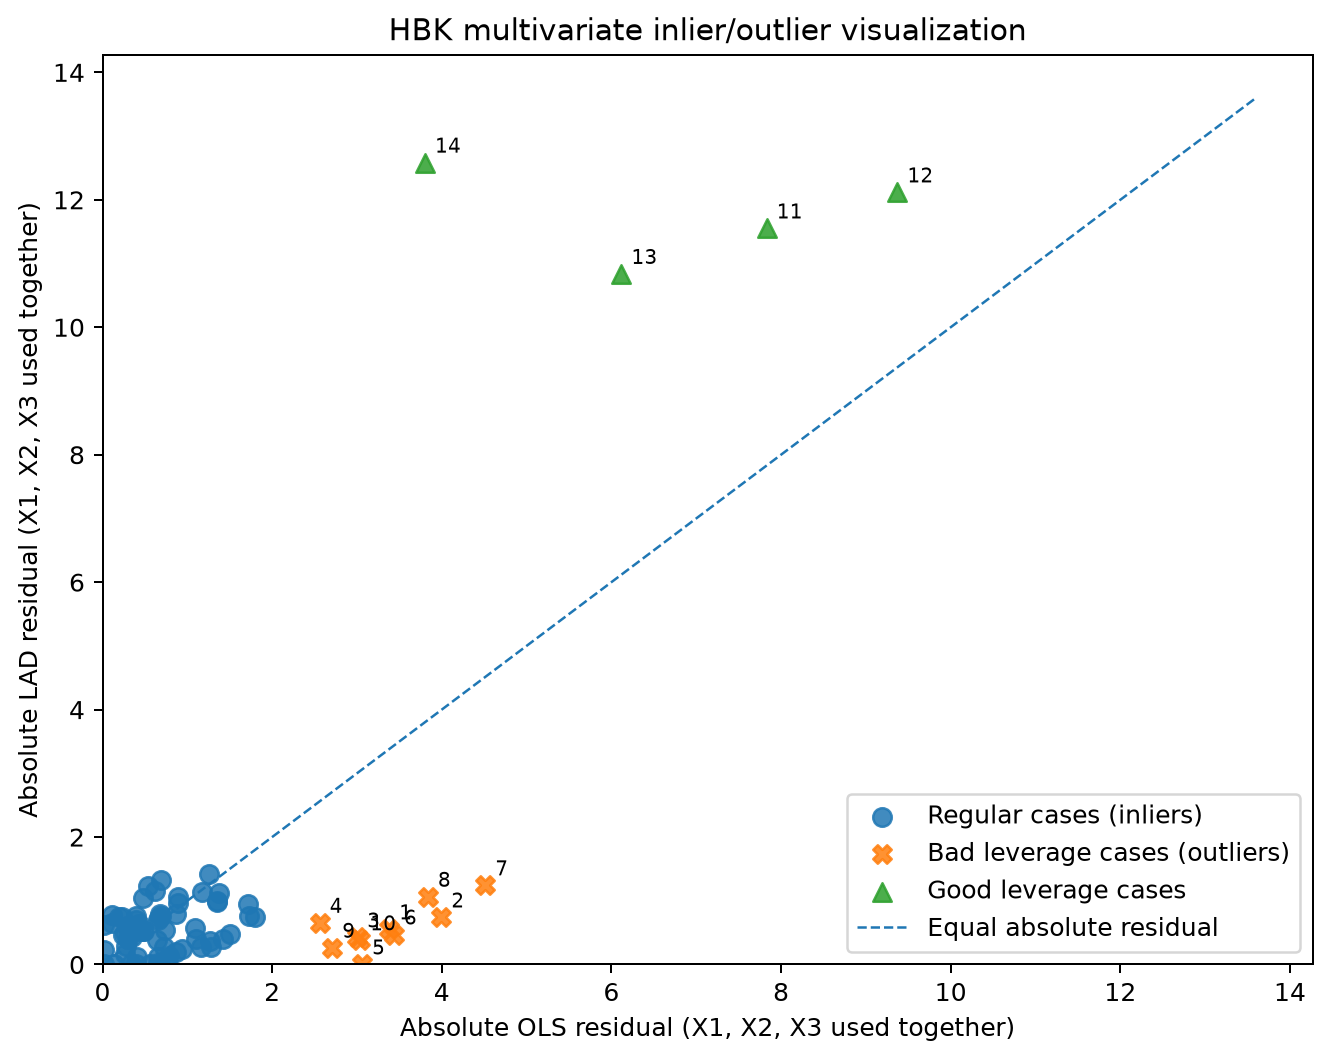

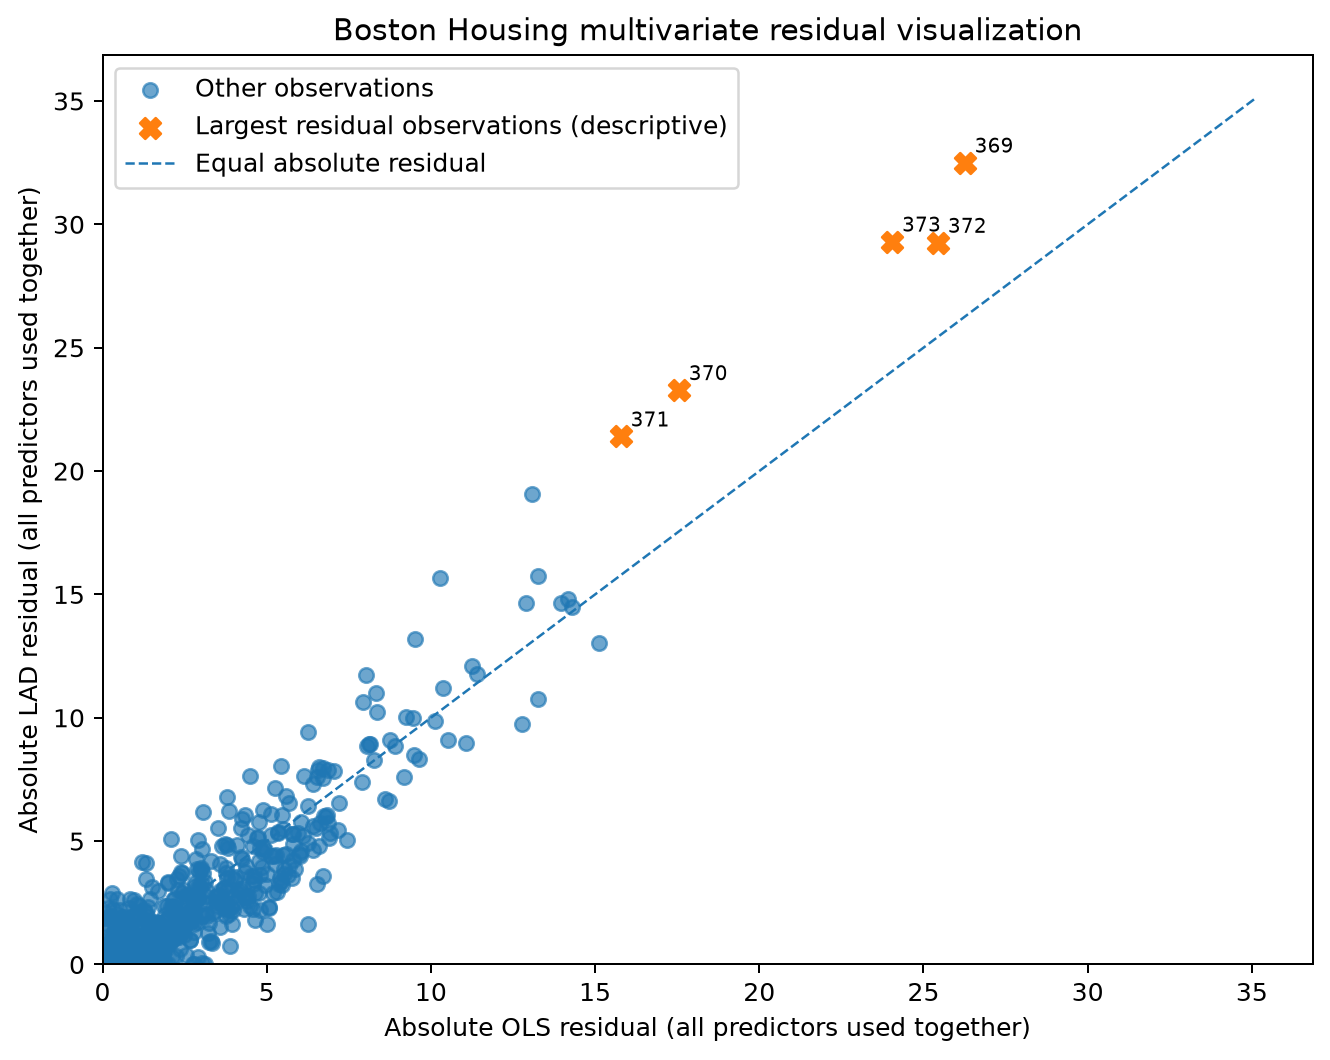

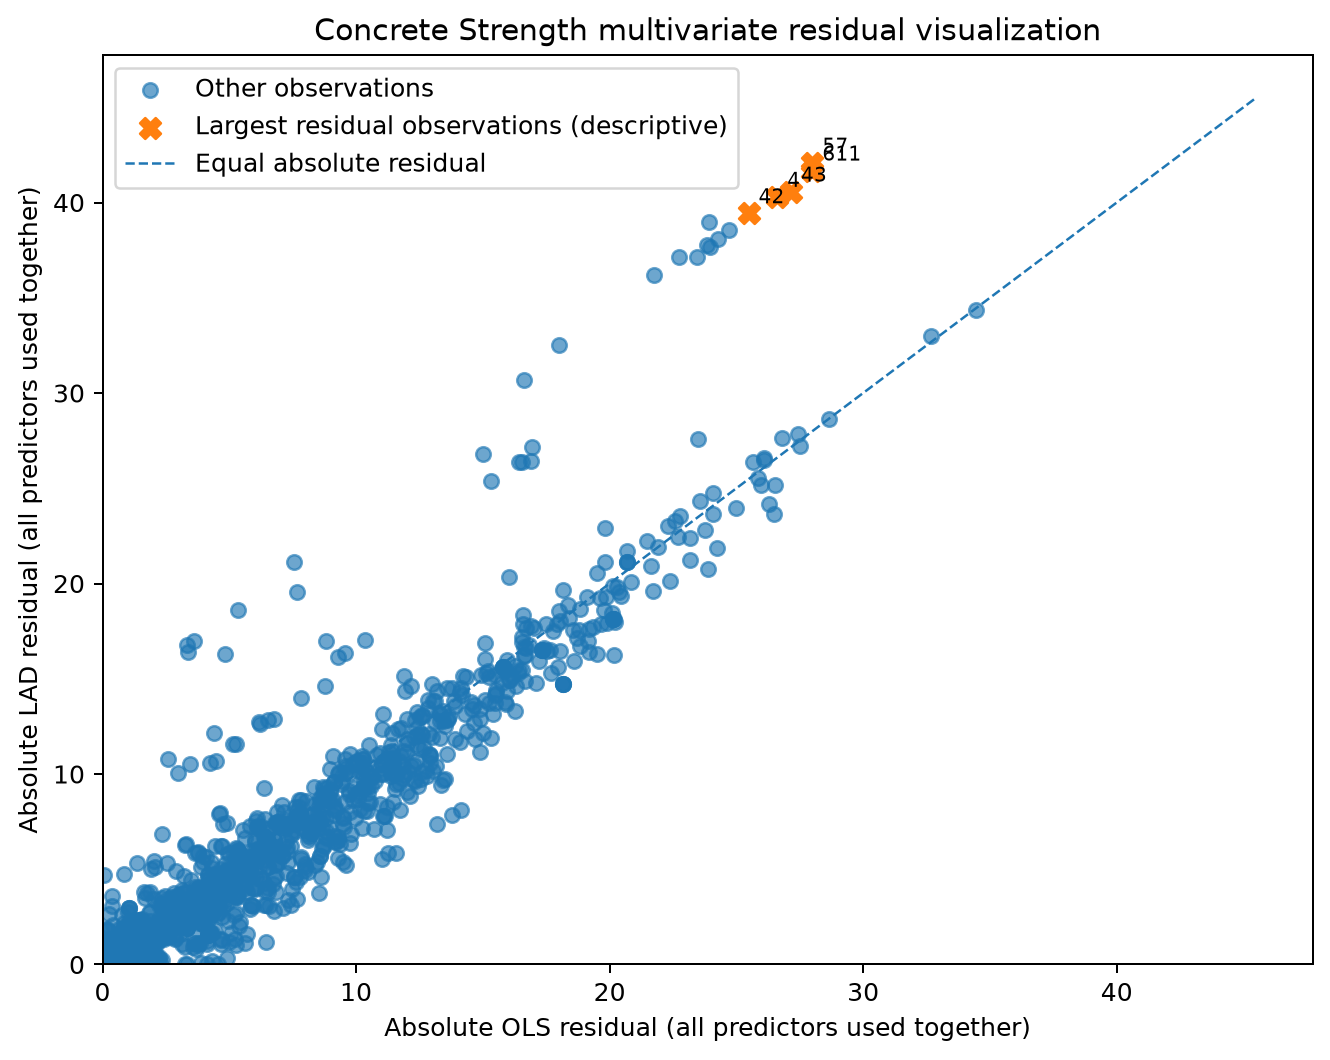

In [4]:
plot_real_dataset_predictions()
plot_hbk_multivariate_inlier_outlier()
plot_unlabeled_multivariate_residual_space("boston_housing", "Boston Housing")
plot_unlabeled_multivariate_residual_space("concrete_strength", "Concrete Strength")

empirical_figures = [
    "boston_housing_actual_vs_fitted.png",
    "concrete_strength_actual_vs_fitted.png",
    "hbk_actual_vs_fitted.png",
    "hbk_multivariate_inlier_outlier.png",
    "boston_housing_multivariate_residuals.png",
    "concrete_strength_multivariate_residuals.png",
]

for filename in empirical_figures:
    path = FIGURE_DIR / filename
    if path.exists():
        display(Image(filename=str(path)))


## 4. Large response-error experiment


In [5]:
contamination_metrics, contamination_changes = run_contamination_experiment()

contamination_summary = (
    contamination_metrics
    .groupby(["contamination_fraction", "model"], as_index=False)[["SSE", "SAE"]]
    .mean()
)
display(contamination_summary)

shift_summary = (
    contamination_changes
    .groupby(["contamination_fraction", "model"], as_index=False)[
        ["coefficient_shift_l2"]
    ]
    .mean()
)
display(shift_summary)


,contamination_fraction,model,SSE,SAE
0,0.00,LAD,182.122968,145.663320
1,0.00,OLS,180.327505,146.546746
2,0.05,LAD,182.037211,145.839431
3,0.05,OLS,834.461729,314.679226
4,0.10,LAD,182.255068,146.184803
5,0.10,OLS,1442.425065,422.602621
6,0.20,LAD,183.746162,147.356557
7,0.20,OLS,3500.582570,658.179060


,contamination_fraction,model,coefficient_shift_l2
0,0.00,LAD,0.000000
1,0.00,OLS,0.000000
2,0.05,LAD,0.028853
3,0.05,OLS,1.660385
4,0.10,LAD,0.064670
5,0.10,OLS,2.397969
6,0.20,LAD,0.135968
7,0.20,OLS,3.860536


## 5. Error-distribution experiment


In [6]:
distribution_results = run_error_distribution_experiment()

distribution_summary = (
    distribution_results
    .groupby(["distribution", "model"], as_index=False)[
        ["coefficient_error_l2", "SSE", "SAE"]
    ]
    .median()
)
display(distribution_summary)


,distribution,model,coefficient_error_l2,SSE,SAE
0,cauchy,LAD,0.267037,36618.163777,677.088736
1,cauchy,OLS,2.497144,35943.810534,830.185744
2,contaminated_normal,LAD,0.184862,1444.597511,216.386353
3,contaminated_normal,OLS,0.472607,1423.420948,224.566884
4,laplace,LAD,0.124388,143.129097,103.909445
5,laplace,OLS,0.162644,140.179326,105.021520
6,normal,LAD,0.186731,148.282634,117.174284
7,normal,OLS,0.153228,145.076526,117.773801


## 6. Runtime benchmark


In [7]:
runtime_results = run_runtime_benchmark()

runtime_summary = (
    runtime_results
    .groupby(["n", "p", "model"], as_index=False)["runtime_seconds"]
    .median()
)
display(runtime_summary)


,n,p,model,runtime_seconds
0,50,1,LAD,0.001850
1,50,1,OLS,0.000069
2,50,3,LAD,0.001978
3,50,3,OLS,0.000044
4,50,5,LAD,0.002124
5,50,5,OLS,0.000051
6,100,1,LAD,0.002792
7,100,1,OLS,0.000047
8,100,3,LAD,0.002973
9,100,3,OLS,0.000046


## 7. Solver validation


In [8]:
validation_results = validate_lad_solver()
display(validation_results)


,example,ols_sse,lad_sse,ols_sae,lad_sae,ols_sse_is_minimum_against_lad,lad_sae_is_minimum_against_ols
0,1,3.621429e+02,676.0,4.085714e+01,26.0,True,True
1,2,9.860761e-32,0.0,4.440892e-16,0.0,True,True


## 8. Generate final figures and outputs


In [9]:
generate_all_figures()

result_files = sorted(path.name for path in RESULT_DIR.glob("*"))
figure_files = sorted(path.name for path in FIGURE_DIR.glob("*"))

display(pd.DataFrame({"result_files": pd.Series(result_files)}))
display(pd.DataFrame({"figure_files": pd.Series(figure_files)}))


,result_files
0,contamination_coefficient_changes.csv
1,contamination_metrics.csv
2,distribution_experiment.csv
3,lad_solver_validation.csv
4,original_data_coefficients.csv
5,original_data_metrics.csv
6,runtime_results.csv


,figure_files
0,boston_housing_actual_vs_fitted.png
1,boston_housing_multivariate_residuals.png
2,coefficient_shift_vs_contamination.png
3,concrete_strength_actual_vs_fitted.png
4,concrete_strength_multivariate_residuals.png
5,error_distribution_comparison.png
6,hbk_actual_vs_fitted.png
7,hbk_multivariate_inlier_outlier.png
8,ols_lad_clean_fit.png
9,ols_lad_contaminated_fit.png


## 9. Experimental summary


In [10]:
summary = original_metrics.pivot(
    index="dataset",
    columns="model",
    values=["SSE", "SAE"],
)
display(summary)


SSE                         SAE             
model                        LAD            OLS          LAD          OLS
dataset                                                                  
boston_housing      12469.793173   11349.418808  1611.011000  1698.290859
concrete_strength  119464.579642  110428.156817  8289.485903  8461.346375
hbk                   587.732546     359.485726    86.742870   103.468960

The experiment compares OLS and LAD on the same empirical data, then examines their behavior under deliberately introduced large response errors, different error distributions, and increasing computational workload. The validation step checks that each implementation minimizes its intended error criterion.
